# Option B Exploration

This notebook contains the exploration component for Option B, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Edge/lane detection using your own images:** Apply edge detection to your own photos. Where does it go wrong? Why might that be the case? Are there other edge detection algorithms that work better?
* **Enhancing the edge detection algorithm** Can you improve the edge detection algorithm somewhere?

For more detailed instructions, please see the [Project 1 Guidelines](https://docs.google.com/document/d/1_yLzSePaVH2OrQgzZsu-1sZ4ez1Da9_tFzZFM3LCarQ/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1:
* Source 2:
* Source 3:
* Source 4:
* Source 5:

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


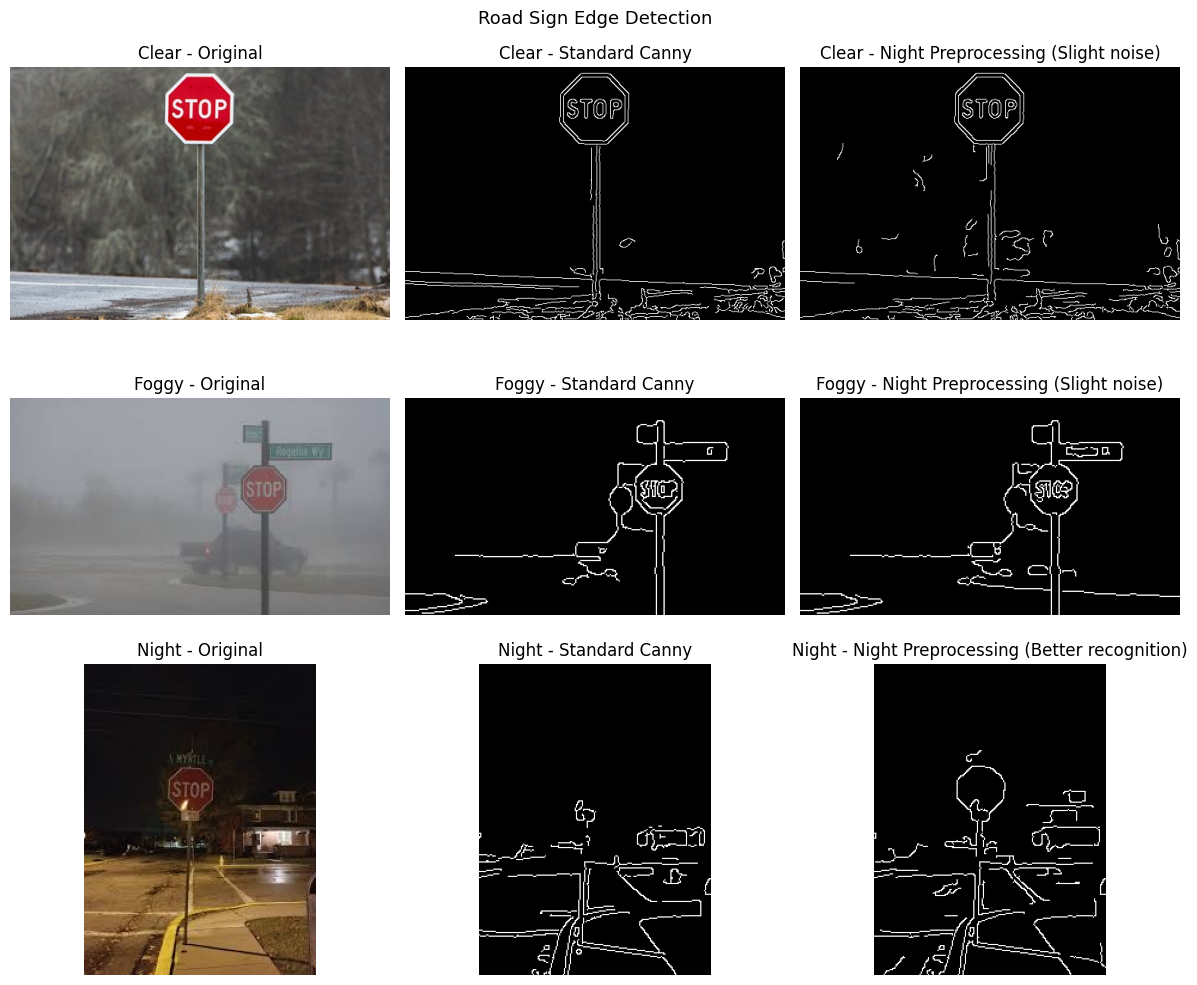

In [6]:
# Please add your code here
# If you do not write your code in this notebook, please attach a link to any code that you wrote!

import numpy as np
import matplotlib.pyplot as plt
from skimage import color, io
import cv2

from edge import gaussian_kernel, conv, gradient, non_maximum_suppression, link_edges


def preprocess(img, night=False):
  # Converts RGB image to grayscale, using condition-specific preprocessing
  # Standard luminance grayscale performed best on daytime images (foggy and clear)
  # For night images, red-channel boosting and moderate CLAHE worked best in dark conditions
    if not night:
        return color.rgb2gray(img.astype(np.float64) / 255.0)
    else:
        r, g, b = img[:,:,0].astype(np.float64), img[:,:,1].astype(np.float64), img[:,:,2].astype(np.float64)
        boosted = np.clip(0.65*r + 0.20*g + 0.15*b, 0, 255).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        return clahe.apply(boosted).astype(np.float64)/255.0


def detect_edges(img, night=False, kernel_size=5, sigma=1.4, high=92, low=75):
    # Run the Canny pipeline from edge.py with adaptive thresholds on an RGB image
    # This means high/low are set as percentiles of NMS values, rather than fixed constants

    gray = preprocess(img, night)
    kernel = gaussian_kernel(kernel_size, sigma)
    smoothed = conv(gray * 255.0, kernel)
    G, theta = gradient(smoothed)
    nms = non_maximum_suppression(G, theta)

    nonzero = nms[nms > 0]
    high = np.percentile(nonzero, high)
    low = np.percentile(nonzero, low)

    strong = nms > high
    weak = (nms <= high) & (nms > low)
    return link_edges(strong, weak)


# Run on images

img_clear = io.imread("clear1.jpeg")
img_fog = io.imread("fog2.jpg")
img_stop = io.imread("stop1.jpg")

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle("Road Sign Edge Detection", fontsize=13)

axes[0, 0].imshow(img_clear); axes[0, 0].set_title("Clear - Original")
axes[0, 1].imshow(detect_edges(img_clear, night=False), cmap="gray"); axes[0, 1].set_title("Clear - Standard Canny")
axes[0, 2].imshow(detect_edges(img_clear, night=True), cmap="gray"); axes[0, 2].set_title("Clear - Night Preprocessing (Slight noise)")

axes[1, 0].imshow(img_fog); axes[1, 0].set_title("Foggy - Original")
axes[1, 1].imshow(detect_edges(img_fog, night=False), cmap="gray"); axes[1, 1].set_title("Foggy - Standard Canny")
axes[1, 2].imshow(detect_edges(img_fog, night=True), cmap="gray"); axes[1, 2].set_title("Foggy - Night Preprocessing (Slight noise)")

axes[2, 0].imshow(img_stop); axes[2, 0].set_title("Night - Original")
axes[2, 1].imshow(detect_edges(img_stop, night=False), cmap="gray"); axes[2, 1].set_title("Night - Standard Canny")
axes[2, 2].imshow(detect_edges(img_stop, night=True), cmap="gray"); axes[2, 2].set_title("Night - Night Preprocessing (Better recognition)")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.savefig("edges_output.png", dpi=150)
plt.show()

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_

**Writeup:**

